# cace's loop with DeepMD's `se_a` descriptor: the SR / LES split on the same 80 frames

The campaign compared two *codes* on one dataset.
This notebook is a narrower question inside the cace half of it: **what changes when the descriptor is DeepMD's `se_a` instead of cace's `Cace`?**

Two arms, trained by `cace/fit_cace_sea.py` on the pod:

| arm | descriptor | what it computes |
|---|---|---|
| `cace-sea-sr` | deepmd `se_a` | `SR_energy -> Forces` (the control) |
| `cace-sea-lr` | deepmd `se_a` | `SR_energy + Ewald(q) -> Forces` |

Everything except the representation is imported from `cace/fit_cace.py` rather than retyped: the schedule (five 40-epoch blocks at E weight 0.1, then 1, 10, 1000), the losses (energy weight ramping, force weight fixed at 1000), the optimizer, the data and the guards.
So the only intended difference from the campaign's `cace-sr` / `cace-lr` is the descriptor and the dimensions downstream of it (`dim_out` 1600 over `nsel` 112, where cace's own representation is 128 wide).

The logging the arms add on top of the shipped recipe is `sea_terms.tsv`: one row per epoch holding the validation split's `E_SR`, `E_LR`, `q` and the `F_SR` / `F_LR` split.
The force split is *measured*, not modelled - cace's `Forces` module derives the force from a named energy key, so re-pointing that key at the sub-energy prices its force exactly.

**This notebook renders at any point in the run.**
FIG 1-4 read `sea_terms.tsv`, which each arm rewrites every epoch, so they fill in as training progresses.
FIG 5-7 all need a *phase* checkpoint, the earliest of which is `model.pth` at epoch 200, and they skip with a message until then.
The validation-selected `best_model.pth` cannot stand in for one: it carries no epoch, so it has no place on a progress axis.
`cace/collect_sweep.py` regenerates every input.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

HERE = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
DATA = os.path.join(HERE, 'data')
assert os.path.isdir(DATA), f'no data dir at {DATA} - run the notebook from analysis/'

# Hue carries the ARM TOPOLOGY - what the model computes - reusing the campaign's own
# semantics for these two slots: blue = short-range only, orange = short-range + Ewald.
# Line style carries the DESCRIPTOR, because the descriptor is the one knob that differs
# between a cace arm and its se_a counterpart, which is this notebook's whole subject - so
# it gets its own channel instead of two more hues. A fifth hue is not available anyway:
# the campaign's palette validator fails the amber<->orange pair on the normal-vision
# floor, so no new hue is introduced here.
HUE = {'sr': '#2a78d6', 'lr': '#eb6834'}
LSB = {'cace': '-', 'sea': (0, (5, 2))}
STYLE = {
    'cace-sr':     {'t': 'sr', 'd': 'cace', 'label': 'cace: SR only'},
    'cace-lr':     {'t': 'lr', 'd': 'cace', 'label': 'cace: SR + Ewald q'},
    'cace-sea-sr': {'t': 'sr', 'd': 'sea',  'label': 'se_a descriptor: SR only'},
    'cace-sea-lr': {'t': 'lr', 'd': 'sea',  'label': 'se_a descriptor: SR + Ewald q'},
}
CACE, SEA = ['cace-sr', 'cace-lr'], ['cace-sea-sr', 'cace-sea-lr']

def arm_colour(arm):
    return HUE[STYLE[arm]['t']]

def arm_style(arm):
    """For plot(): colour + linestyle. scatter() needs arm_colour() instead."""
    return dict(color=arm_colour(arm), ls=LSB[STYLE[arm]['d']])

def arm_label(arm):
    return STYLE[arm]['label']

SURFACE = '#fcfcfb'
INK, INK2, INK3 = '#0b0b0b', '#52514e', '#8a8981'
mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': INK3, 'axes.linewidth': 0.8,
    'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.titlesize': 11, 'axes.labelsize': 9.5,
    'xtick.color': INK2, 'ytick.color': INK2,
    'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5,
    'grid.color': '#e6e5e1', 'grid.linewidth': 0.7,
    'legend.frameon': False, 'legend.fontsize': 8.5,
    'font.size': 9.5, 'figure.dpi': 110,
})

def tidy_grid(ax, title='', xlabel='', ylabel=''):
    ax.grid(True, which='major', alpha=0.9)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    if title:  ax.set_title(title, loc='left', pad=8)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)

def load(name, cols, required=False):
    """Read a collected TSV. Absent is fine and loud; a missing column is not."""
    p = os.path.join(DATA, name)
    if not os.path.exists(p):
        if required:
            raise FileNotFoundError(f'{p} is required - run cace/collect_sweep.py')
        print(f'{name:30s} absent')
        return pd.DataFrame(columns=cols)
    d = pd.read_csv(p, sep='\t')
    missing = [c for c in cols if c not in d.columns]
    if missing:
        raise ValueError(f'{name} is missing {missing} - was it collected by an older '
                         f'collect_sweep.py?')
    print(f'{name:30s} {len(d):5d} rows   arms {sorted(d["arm"].unique())}')
    return d

## Load the data

Four files, all written by `cace/collect_sweep.py`: the epoch traces of both families, the sea arms' per-epoch decomposition, and the scored checkpoints.
The `best_model.pth` row is present in the scored tables but is excluded from every mean here, and drawn flagged rather than dropped - an open circle in FIG 6, a dashed tick in FIG 7 - because it was selected on exactly the 80 frames everything is scored on.
FIG 5 cannot do even that: it is a progress axis and no epoch is recorded for that checkpoint.

In [2]:
EP_COLS = ['arm', 'global_epoch', 'block', 'block_epoch', 'phase', 'energy_weight',
           'lr', 'train_loss', 'val_loss']
ep = pd.concat([load('cace_epoch_metrics.tsv', EP_COLS),
                load('cace_sea_epoch_metrics.tsv', EP_COLS, required=True)],
               ignore_index=True)

TERM_COLS = ['arm', 'global_epoch', 'phase', 'block', 'block_epoch',
             'val_e_sr_mean', 'val_e_sr_rms', 'val_e_lr_mean', 'val_e_lr_std',
             'val_e_lr_rms', 'val_q_mean', 'val_q_rms', 'val_q_max_abs',
             'val_net_charge', 'val_sum_q2', 'val_f_sr_rms', 'val_f_lr_rms',
             'val_f_tot_rms', 'val_f_lr_over_f_tot']
terms = load('cace_sea_terms.tsv', TERM_COLS, required=True)
# The SR arm's E_SR column is its whole energy; the LR arm's is one channel of two.
# This derived column is each arm's TOTAL, so the two are comparable in one line.
terms['val_e_tot_mean'] = np.where(terms['val_e_lr_mean'].isna(),
                                   terms['val_e_sr_mean'],
                                   terms['val_e_sr_mean'] + terms['val_e_lr_mean'])

SCORE_COLS = ['arm', 'step', 'epoch', 'ckpt', 'val_selected', 'rmse_e_peratom',
              'rmse_f', 'natoms', 'nframes', 'e_r2', 'f_r2', 'bias', 'spread',
              'bias2_over_rmse2', 'f_lr_over_f_tot', 'f_self_over_f_tot',
              'e_lr_mean_ev_per_frame', 'e_lr_std_ev_per_frame',
              'net_charge_mean_per_frame', 'sum_q2_mean_per_frame',
              'remove_self_interaction', 'model_sha256_12', 'head_n_in', 'seed']
score = pd.concat([load('cace_valid.tsv', SCORE_COLS),
                   load('cace_sea_valid.tsv', SCORE_COLS)], ignore_index=True)
# `score` holds every scored row. What the figures use is the four phase checkpoints, and
# `best_model.pth` fails both of their requirements: it was elected on these very 80
# frames, and `collect_sweep.py` records no epoch for it (STEMS). With no epoch it cannot
# even be placed on a progress axis, so it is reported in the tables and never drawn.
scored = score[score['val_selected'] == 0].copy()
HAVE_SEA_PHASE = bool(len(scored) and scored['arm'].isin(SEA).any())
print(f'scored rows {len(score)}, of which sea {int(score["arm"].isin(SEA).sum())}; '
      f'drawable phase checkpoints {len(scored)}   -> HAVE_SEA_PHASE {HAVE_SEA_PHASE}')
if len(scored):
    print(scored.groupby('arm').agg(n=('rmse_f', 'size'), epochs=('epoch', 'max'),
                                    head_n_in=('head_n_in', 'max')).to_string())


cace_epoch_metrics.tsv          1000 rows   arms ['cace-lr', 'cace-sr']
cace_sea_epoch_metrics.tsv      1000 rows   arms ['cace-sea-lr', 'cace-sea-sr']
cace_sea_terms.tsv              1000 rows   arms ['cace-sea-lr', 'cace-sea-sr']
cace_valid.tsv                    10 rows   arms ['cace-lr', 'cace-sr']
cace_sea_valid.tsv                10 rows   arms ['cace-sea-lr', 'cace-sea-sr']
scored rows 20, of which sea 10; drawable phase checkpoints 16   -> HAVE_SEA_PHASE True
             n  epochs  head_n_in
arm                              
cace-lr      4   500.0        NaN
cace-sea-lr  4   500.0     1600.0
cace-sea-sr  4   500.0     1600.0
cace-sr      4   500.0        NaN


## FIG 1 - The training trace, both families on one axis

All four arms ran through the same cace `TrainingTask`, so the loss is in the same units and the same code path at every point - this is a fair line-by-line comparison.
The verticals are the energy-weight phase boundaries, read off the trace rather than hardcoded.

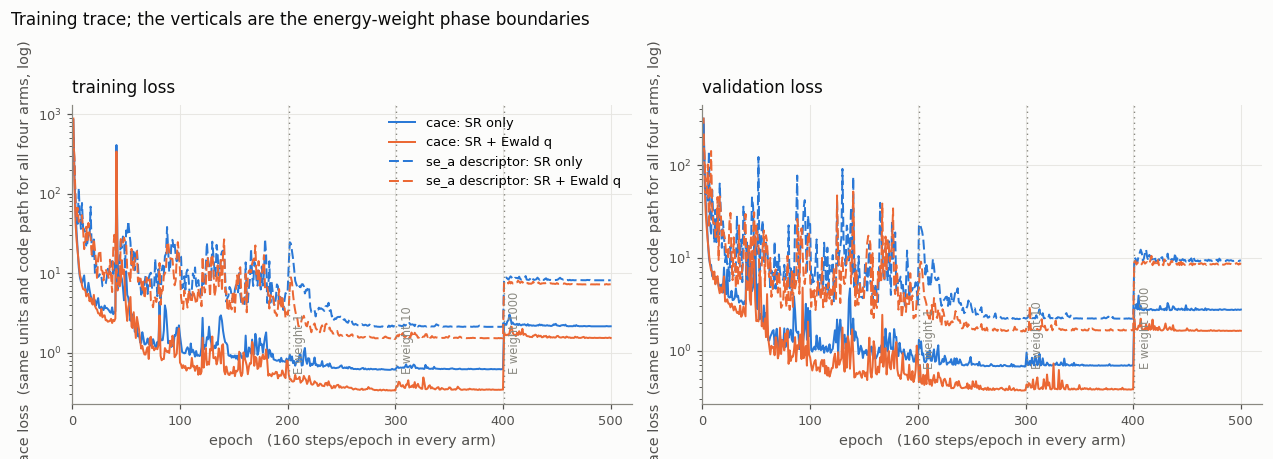

             epochs  last_epoch  train_last  val_last
arm                                                  
cace-lr         500         500      1.5357    1.6340
cace-sea-lr     500         500      7.2536    8.4572
cace-sea-sr     500         500      8.1662    9.4061
cace-sr         500         500      2.1573    2.7674


In [3]:
if ep.empty:
    print('SKIP FIG 1: no epoch traces collected yet')
else:
    arms = [a for a in CACE + SEA if a in set(ep['arm'])]
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.2))
    for arm in arms:
        d = ep[ep['arm'] == arm].sort_values('global_epoch')
        for ax, col in ((axes[0], 'train_loss'), (axes[1], 'val_loss')):
            ax.plot(d['global_epoch'], d[col], lw=1.3, label=arm_label(arm),
                    **arm_style(arm))
    bounds = ep.groupby('energy_weight')['global_epoch'].min().sort_values()
    for ax, t in zip(axes, ('training loss', 'validation loss')):
        ax.set_yscale('log')
        for w, e in bounds.items():
            if e <= 1:
                continue
            ax.axvline(e, color=INK3, lw=0.9, ls=(0, (1, 3)))
            ax.text(e + 5, ax.get_ylim()[0] * 2.4, f'E weight {w:g}', fontsize=7.5,
                    color=INK3, rotation=90, va='bottom', ha='left')
        ax.set_xlim(0, max(ep['global_epoch'].max() * 1.04, 10))
        tidy_grid(ax, t, 'epoch   (160 steps/epoch in every arm)',
                  'cace loss  (same units and code path for all four arms, log)')
    axes[0].legend(loc='best')
    fig.suptitle('Training trace; the verticals are the energy-weight phase boundaries',
                 x=0.007, ha='left', fontsize=11, color=INK)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()
    print(ep.groupby('arm').agg(epochs=('global_epoch', 'count'),
                                last_epoch=('global_epoch', 'max'),
                                train_last=('train_loss', 'last'),
                                val_last=('val_loss', 'last')).to_string())

## FIG 2 - What each arm puts in the energy channels

Both arms fit the same target.
The SR-only arm spends its whole output on the short-range channel; the SR+Ewald arm splits the same total into a short-range head and the Ewald sum over its learned charges.
The left panel is the short-range channel of each, the right is the long-range channel (which only the SR+Ewald arm has) with its frame-to-frame spread as a band.

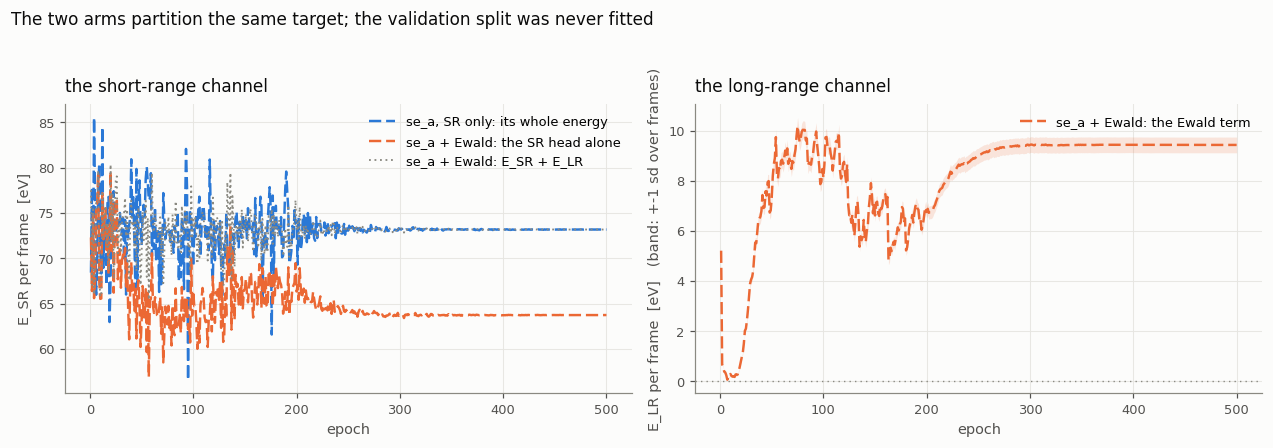

        arm  global_epoch  val_e_sr_mean  val_e_lr_mean  val_e_lr_std  val_e_tot_mean
cace-sea-sr           500      73.167282            NaN           NaN       73.167282
cace-sea-lr           500      63.740063       9.432928      0.313383       73.172991


In [4]:
d_sr = terms[terms['arm'] == 'cace-sea-sr'].sort_values('global_epoch')
d_lr = terms[terms['arm'] == 'cace-sea-lr'].sort_values('global_epoch')
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.1))

axes[0].plot(d_sr['global_epoch'], d_sr['val_e_sr_mean'], lw=1.6,
             label='se_a, SR only: its whole energy', **arm_style('cace-sea-sr'))
axes[0].plot(d_lr['global_epoch'], d_lr['val_e_sr_mean'], lw=1.6,
             label='se_a + Ewald: the SR head alone', **arm_style('cace-sea-lr'))
axes[0].plot(d_lr['global_epoch'], d_lr['val_e_tot_mean'], lw=1.2, color=INK3,
             ls=(0, (1, 2)), label='se_a + Ewald: E_SR + E_LR')
axes[1].plot(d_lr['global_epoch'], d_lr['val_e_lr_mean'], lw=1.6,
             label='se_a + Ewald: the Ewald term', **arm_style('cace-sea-lr'))
axes[1].fill_between(d_lr['global_epoch'],
                     d_lr['val_e_lr_mean'] - d_lr['val_e_lr_std'],
                     d_lr['val_e_lr_mean'] + d_lr['val_e_lr_std'],
                     color=HUE['lr'], alpha=0.16, lw=0)
axes[1].axhline(0.0, color=INK3, lw=0.9, ls=(0, (1, 3)))

tidy_grid(axes[0], 'the short-range channel', 'epoch', 'E_SR per frame  [eV]')
tidy_grid(axes[1], 'the long-range channel', 'epoch',
          'E_LR per frame  [eV]   (band: +-1 sd over frames)')
axes[0].legend(loc='best')
axes[1].legend(loc='best')
fig.suptitle('The two arms partition the same target; the validation split was never fitted',
             x=0.007, ha='left', fontsize=11, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

last = terms.sort_values('global_epoch').groupby('arm').tail(1)
print(last[['arm', 'global_epoch', 'val_e_sr_mean', 'val_e_lr_mean', 'val_e_lr_std',
            'val_e_tot_mean']].to_string(index=False))

## FIG 3 - What each channel contributes to the force

Forces are the gradient of a named energy in this codebase, so the split here is measured rather than assumed: each channel's force is the gradient of that channel alone, on a fresh batch.
Panels 2 and 3 are inside the SR+Ewald arm, so their two curves are distinguished by line style and named in the legend rather than by a third hue.

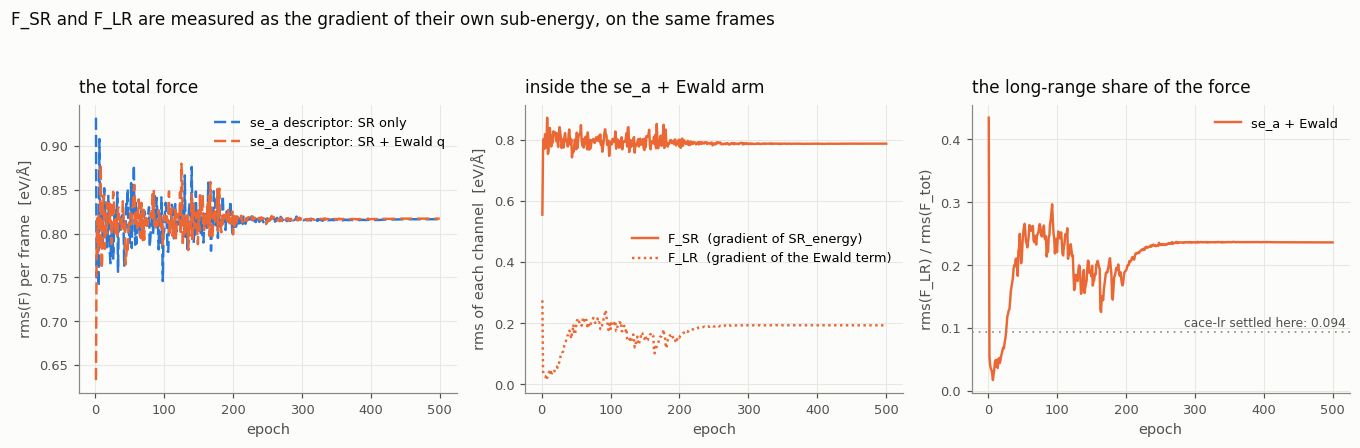

        arm  global_epoch  val_f_sr_rms  val_f_lr_rms  val_f_tot_rms  val_f_lr_over_f_tot
cace-sea-sr           500      0.816512           NaN       0.816512                  NaN
cace-sea-lr           500      0.787854      0.193104       0.817219             0.236294


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.1))

for arm in ('cace-sea-sr', 'cace-sea-lr'):
    d = terms[terms['arm'] == arm].sort_values('global_epoch')
    axes[0].plot(d['global_epoch'], d['val_f_tot_rms'], lw=1.6, label=arm_label(arm),
                 **arm_style(arm))
    if arm == 'cace-sea-lr':
        axes[1].plot(d['global_epoch'], d['val_f_sr_rms'], lw=1.6, color=HUE['lr'],
                     ls='-', label='F_SR  (gradient of SR_energy)')
        axes[1].plot(d['global_epoch'], d['val_f_lr_rms'], lw=1.6, color=HUE['lr'],
                     ls=(0, (1, 1.4)), label='F_LR  (gradient of the Ewald term)')
        axes[2].plot(d['global_epoch'], d['val_f_lr_over_f_tot'], lw=1.6,
                     color=HUE['lr'], ls='-', label='se_a + Ewald')

# what the campaign's Cace-descriptor long-range arm settled at, for scale only:
# it is a different representation, so it is a reference line, not a peer series
if len(scored) and (scored['arm'] == 'cace-lr').any():
    v = scored[scored['arm'] == 'cace-lr']['f_lr_over_f_tot'].mean()
    axes[2].axhline(v, color=INK3, lw=1.1, ls=(0, (1, 3)))
    axes[2].text(axes[2].get_xlim()[1] * 0.99, v + 0.004, f'cace-lr settled here: {v:.3f}',
                 fontsize=8, color=INK2, ha='right', va='bottom')

tidy_grid(axes[0], 'the total force', 'epoch', 'rms(F) per frame  [eV/Å]')
tidy_grid(axes[1], 'inside the se_a + Ewald arm', 'epoch', 'rms of each channel  [eV/Å]')
tidy_grid(axes[2], 'the long-range share of the force', 'epoch', 'rms(F_LR) / rms(F_tot)')
for ax in axes:
    ax.legend(loc='best')
fig.suptitle('F_SR and F_LR are measured as the gradient of their own sub-energy, on the same frames',
             x=0.007, ha='left', fontsize=11, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

print(terms.sort_values('global_epoch').groupby('arm').tail(1)[
    ['arm', 'global_epoch', 'val_f_sr_rms', 'val_f_lr_rms', 'val_f_tot_rms',
     'val_f_lr_over_f_tot']].to_string(index=False))

## FIG 4 - The charge channel

The latent charges are a function of geometry: a small network reads the descriptor and predicts one charge per atom, and those charges are what the Ewald sum runs on.
There is no per-atom charge parameter anywhere, so a charge cannot be memorised by atom identity.
These four panels are the charge channel's own state over training.

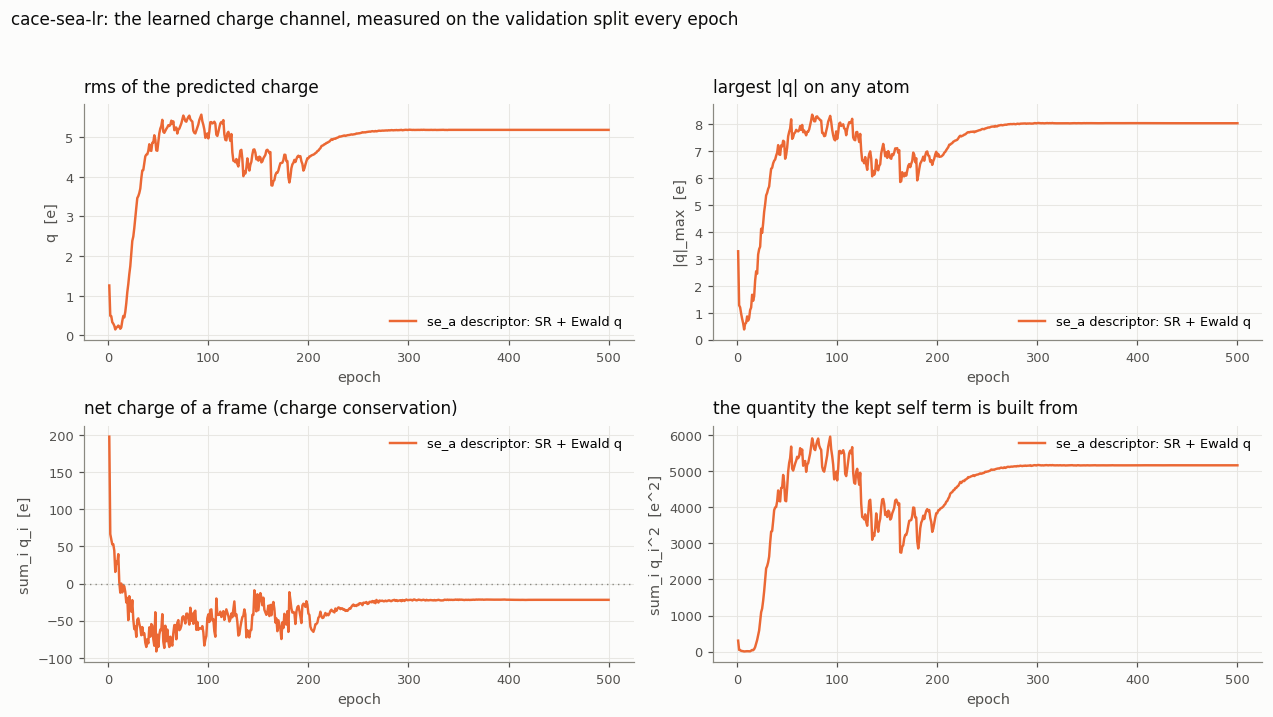

        arm  global_epoch  val_q_mean  val_q_rms  val_q_max_abs  val_net_charge  val_sum_q2
cace-sea-sr           500         NaN        NaN            NaN             NaN         NaN
cace-sea-lr           500   -0.114205   5.185746       8.030352      -21.927334  5163.25684


In [6]:
panels = [('val_q_rms', 'rms of the predicted charge', 'q  [e]'),
          ('val_q_max_abs', 'largest |q| on any atom', '|q|_max  [e]'),
          ('val_net_charge', 'net charge of a frame (charge conservation)',
           'sum_i q_i  [e]'),
          ('val_sum_q2', 'the quantity the kept self term is built from',
           'sum_i q_i^2  [e^2]')]
fig, axes = plt.subplots(2, 2, figsize=(11.6, 6.6))
for ax, (col, title, ylab) in zip(axes.ravel(), panels):
    ax.plot(d_lr['global_epoch'], d_lr[col], lw=1.6, color=HUE['lr'],
            label=arm_label('cace-sea-lr'))
    if col == 'val_net_charge':
        ax.axhline(0.0, color=INK3, lw=0.9, ls=(0, (1, 3)))
    tidy_grid(ax, title, 'epoch', ylab)
    ax.legend(loc='best')
fig.suptitle('cace-sea-lr: the learned charge channel, measured on the validation split every epoch',
             x=0.007, ha='left', fontsize=11, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.955))
plt.show()

print(terms.sort_values('global_epoch').groupby('arm').tail(1)[
    ['arm', 'global_epoch', 'val_q_mean', 'val_q_rms', 'val_q_max_abs',
     'val_net_charge', 'val_sum_q2']].to_string(index=False))

## FIG 5 - Full-split error against training progress

Every phase checkpoint, scored on the same 80 frames with the same `cace/score_cace.py` pass.
The four phase checkpoints land at epochs 200, 300, 400 and 500, which is the same amount of work as the deepmd arms' 80k steps (160 steps per epoch).
The validation-selected `best_model.pth` is absent from this axis only because it has no epoch - FIG 6 shows it, flagged.

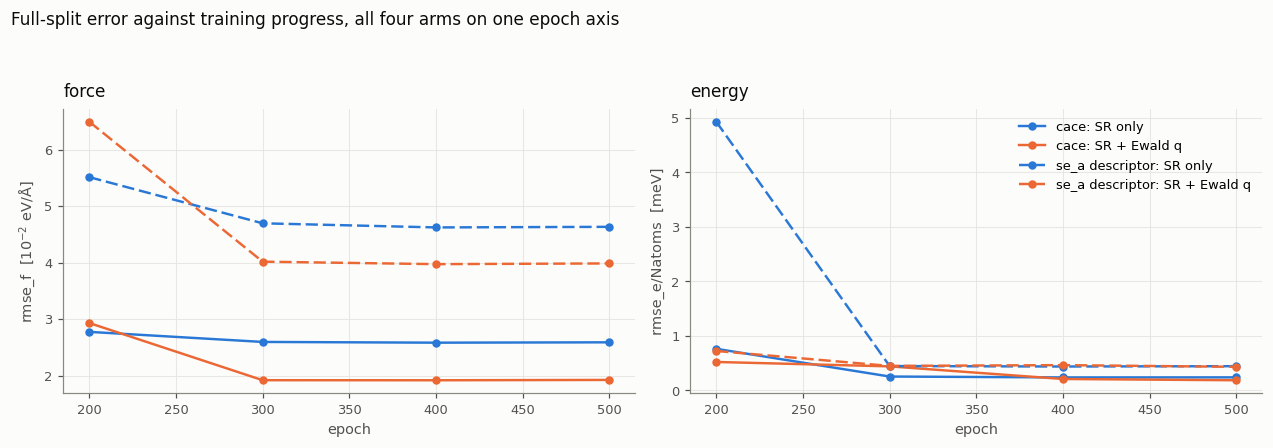

change over the last two kept checkpoints:
  cace-sr                f  +0.25%   e  +0.42%
  cace-lr                f  +0.31%   e -11.17%
  cace-sea-sr            f  +0.23%   e  +1.40%
  cace-sea-lr            f  +0.32%   e  -6.79%


In [7]:
if not HAVE_SEA_PHASE:
    print('SKIP FIG 5: no se_a phase checkpoint scored yet. The validation-selected')
    print('          best_model.pth is not a substitute - it carries no epoch, so it')
    print('          has no place on a progress axis. First such file: epoch 200.')
else:
    arms = [a for a in CACE + SEA if a in set(scored['arm'])]
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.1))
    for arm in arms:
        g = scored[scored['arm'] == arm].sort_values('epoch')
        axes[0].plot(g['epoch'], g['rmse_f'] * 1e2, marker='o', ms=4.5, lw=1.6,
                     label=arm_label(arm), **arm_style(arm))
        axes[1].plot(g['epoch'], g['rmse_e_peratom'] * 1e3, marker='o', ms=4.5, lw=1.6,
                     label=arm_label(arm), **arm_style(arm))
    tidy_grid(axes[0], 'force', 'epoch', 'rmse_f  [$10^{-2}$ eV/Å]')
    tidy_grid(axes[1], 'energy', 'epoch', 'rmse_e/Natoms  [meV]')
    axes[1].legend(loc='best')
    fig.suptitle('Full-split error against training progress, all four arms on one epoch axis',
                 x=0.007, ha='left', fontsize=11, color=INK)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()

    print('change over the last two kept checkpoints:')
    for arm in arms:
        v = scored[scored['arm'] == arm].sort_values('epoch')
        if len(v) >= 2:
            print(f'  {arm:22s} f {(v["rmse_f"].iloc[-1] - v["rmse_f"].iloc[-2]) / v["rmse_f"].iloc[-2] * 100:+6.2f}%'
                  f'   e {(v["rmse_e_peratom"].iloc[-1] - v["rmse_e_peratom"].iloc[-2]) / v["rmse_e_peratom"].iloc[-2] * 100:+6.2f}%')


## FIG 6 - The headline: final accuracy on the same 80 frames

The mean over each arm's own phase checkpoints - four per arm once a run is complete, at epochs 200, 300, 400 and 500 - with each checkpoint shown as a point so the spread and the trend are visible rather than averaged away.
The validation-selected `best_model.pth` is drawn beside its arm but kept out of the mean, for two reasons: it was elected on these very 80 frames, and cace's `fit` resets its best-loss tracker on every call while each phase raises the energy weight, so it holds the best epoch of the final phase rather than of the run.
A bar from zero would exaggerate the gaps, so the mark is a point and a mean tick.

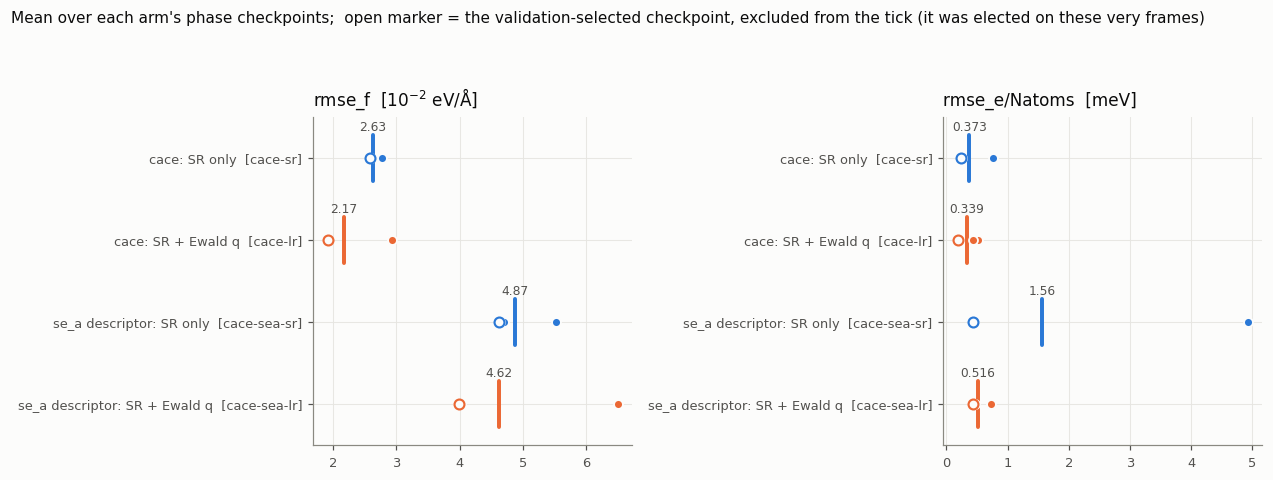


rmse_f [1e-2 eV/A]
  cace-sr                mean    2.6345  n=4  min    2.5818   max    2.7732   selected    2.5853
  cace-lr                mean    2.1711  n=4  min    1.9157   max    2.9300   selected    1.9217
  cace-sea-sr            mean    4.8674  n=4  min    4.6238   max    5.5146   selected    4.6246
  cace-sea-lr            mean    4.6182  n=4  min    3.9732   max    6.4963   selected    3.9844

rmse_e [meV]
  cace-sr                mean    0.3730  n=4  min    0.2375   max    0.7621   selected    0.2358
  cace-lr                mean    0.3387  n=4  min    0.1852   max    0.5210   selected    0.1848
  cace-sea-sr            mean    1.5637  n=4  min    0.4376   max    4.9275   selected    0.4337
  cace-sea-lr            mean    0.5164  n=4  min    0.4316   max    0.7227   selected    0.4272


In [8]:
if not HAVE_SEA_PHASE:
    print('SKIP FIG 6: no se_a phase checkpoint scored yet, so the panel would show two')
    print('          of four arms. The four model*.pth start at epoch 200.')
else:
    arms = [a for a in CACE + SEA if a in set(scored['arm'])]
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))
    for ax, col, scale, lab in ((axes[0], 'rmse_f', 1e2, 'rmse_f  [$10^{-2}$ eV/Å]'),
                                (axes[1], 'rmse_e_peratom', 1e3, 'rmse_e/Natoms  [meV]')):
        for i, arm in enumerate(arms):
            v = scored[scored['arm'] == arm][col].values * scale
            ax.scatter(v, np.full(len(v), i), s=34, marker='o', zorder=3,
                       color=arm_colour(arm), edgecolor=SURFACE, linewidth=1.2)
            ax.plot([v.mean(), v.mean()], [i - 0.28, i + 0.28], lw=2.6,
                    solid_capstyle='round', color=arm_colour(arm), zorder=2)
            ax.text(v.mean(), i - 0.46, f'{v.mean():.3g}', ha='center', va='top',
                    fontsize=8, color=INK2)
            # The validation-selected checkpoint, drawn open and outside the mean tick.
            # On THIS axis it is a value, not an epoch, so unlike FIG 5 it has a place.
            s = score[(score['arm'] == arm)
                      & (score['val_selected'] != 0)][col].values * scale
            ax.scatter(s, np.full(len(s), i), s=42, marker='o', facecolor=SURFACE,
                       edgecolor=arm_colour(arm), linewidth=1.4, zorder=4)
        ax.set_yticks(np.arange(len(arms)))
        ax.set_yticklabels([f'{arm_label(a)}  [{a}]' for a in arms], fontsize=8.5)
        ax.set_ylim(len(arms) - 0.5, -0.5)
        tidy_grid(ax, lab)
    fig.suptitle("Mean over each arm's phase checkpoints;  open marker = the validation-selected "
                 'checkpoint, excluded from the tick (it was elected on these very frames)',
                 x=0.007, ha='left', fontsize=10, color=INK)
    fig.tight_layout(rect=(0, 0, 1, 0.92))
    plt.show()

    for col, scale, lab in (('rmse_f', 1e2, 'rmse_f [1e-2 eV/A]'),
                            ('rmse_e_peratom', 1e3, 'rmse_e [meV]')):
        print(f'\n{lab}')
        for arm in arms:
            v = scored[scored['arm'] == arm][col] * scale
            s = score[(score['arm'] == arm) & (score['val_selected'] != 0)][col] * scale
            sel = f'   selected {float(s.iloc[0]):9.4f}' if len(s) else ''
            print(f'  {arm:22s} mean {v.mean():9.4f}  n={len(v)}  '
                  f'min {v.min():9.4f}   max {v.max():9.4f}{sel}')


## FIG 7 - What the long-range channel is worth, priced the same way in both arms

`F_LR` is the gradient of the Ewald term alone and `F_self` is the gradient of the self-interaction term the kernel keeps (`remove_self_interaction=False` in both codes).
Both are shares of the total force, so they compare across arms regardless of how large each arm's forces are.

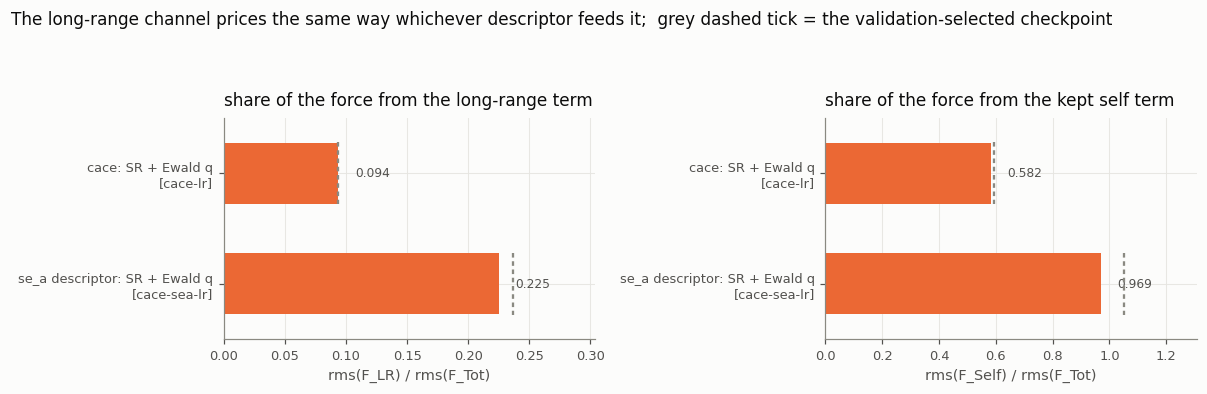

        arm  epoch   rmse_f  rmse_e_peratom  e_lr_mean_ev_per_frame  f_lr_over_f_tot  f_self_over_f_tot  net_charge_mean_per_frame  sum_q2_mean_per_frame
    cace-lr  200.0 0.029300        0.000521                2.444036         0.093772           0.550191                  12.180875             1207.73474
    cace-lr  300.0 0.019169        0.000440                2.520526         0.093448           0.592490                   7.240059             1222.94006
    cace-lr  400.0 0.019157        0.000209                2.524236         0.093786           0.593059                   7.356977             1224.46216
    cace-lr  500.0 0.019216        0.000185                2.533643         0.093681           0.593554                   6.911968             1228.06763
cace-sea-lr  200.0 0.064963        0.000723                6.755763         0.191468           0.720137                 -40.347450             3836.12842
cace-sea-lr  300.0 0.040172        0.000448                9.435869         

In [9]:
lr_arms = [a for a in CACE + SEA if a in set(scored['arm'])
           and scored[scored['arm'] == a]['f_lr_over_f_tot'].notna().any()]
# the requirement is specifically the se_a + Ewald arm: with only cace-lr present the
# panel would draw one bar under a two-descriptor claim
if not any(a in lr_arms for a in SEA):
    print('SKIP FIG 7: no se_a + Ewald arm has a phase checkpoint scored yet, so there is')
    print('          nothing to compare cace-lr against (needs cace-sea-lr/model.pth at')
    print('          epoch 200; best_model.pth is not a substitute, it has no epoch).')
else:
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.6))
    y = np.arange(len(lr_arms))
    for ax, col, title, xl in (
            (axes[0], 'f_lr_over_f_tot', 'share of the force from the long-range term',
             'rms(F_LR) / rms(F_Tot)'),
            (axes[1], 'f_self_over_f_tot', 'share of the force from the kept self term',
             'rms(F_Self) / rms(F_Tot)')):
        vals = np.array([scored[scored['arm'] == a][col].mean() for a in lr_arms])
        ax.barh(y, vals, height=0.55, color=[arm_colour(a) for a in lr_arms])
        for i, a in enumerate(lr_arms):
            # 6% of the widest bar, not 2%: the dashed tick below can sit a hair
            # past the bar's end, and 2% put the number within 2 px of it
            ax.text(vals[i] + vals.max() * 0.06, i, f'{vals[i]:.3f}', va='center',
                    ha='left', fontsize=8, color=INK2)
            # reported, never averaged: the selected checkpoint is a tick, not a bar
            s = score[(score['arm'] == a) & (score['val_selected'] != 0)][col].values
            ax.plot([s, s], [i - 0.28, i + 0.28], color=INK3, lw=1.5,
                    ls=(0, (2, 1.6)), zorder=4)
        ax.set_yticks(y)
        ax.set_yticklabels([f'{arm_label(a)}\n[{a}]' for a in lr_arms], fontsize=8.5)
        ax.set_ylim(len(lr_arms) - 0.5, -0.5)
        ax.set_xlim(0, vals.max() * 1.35)
        tidy_grid(ax, title, xl)
    fig.suptitle('The long-range channel prices the same way whichever descriptor feeds it;  '
                 'grey dashed tick = the validation-selected checkpoint',
                 x=0.007, ha='left', fontsize=11, color=INK)
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    plt.show()

    cols = ['arm', 'epoch', 'rmse_f', 'rmse_e_peratom', 'e_lr_mean_ev_per_frame',
            'f_lr_over_f_tot', 'f_self_over_f_tot', 'net_charge_mean_per_frame',
            'sum_q2_mean_per_frame']
    print(scored[scored['arm'].isin(lr_arms)][cols].to_string(index=False))
    sel = score[score['arm'].isin(lr_arms) & (score['val_selected'] != 0)]
    if len(sel):
        print('\nvalidation-selected, excluded from the bars above:')
        print(sel[cols].to_string(index=False))


## FIG 8 - The average charge each element carries, through training

Both charge-bearing arms predict one charge per atom from the descriptor, so the charge is a function of geometry and never of atom identity.
This figure reads that charge out of the scorer's own per-atom arrays and splits it by element: oxygen on the left, hydrogen in the middle, and on the right the one arm whose per-epoch trace we have.

The four phase-end checkpoints are what the rest of the notebook scores, so they are what this figure plots; `best_model.pth` is left out for the two reasons FIG 6 gives (it was elected on these very 80 frames, and it carries no epoch to plot against).
Both arms are the `SR + Ewald q` topology, so both wear the orange hue and the descriptor is the channel that separates them: solid for cace's `Cace` representation, dashed for DeepMD's `se_a`, exactly as in FIG 4.

The **global sign of q is a gauge, not a measurement**.
`E_LR = q^T K(r) q` and `F_LR = q^T (dK/dr) q` are both even in q, and the short-range half never sees q at all, so an arm that predicts `-q` everywhere is the same arm.
`cace-sea-lr`'s own optimizer crossed q = 0 early in training (epoch ~12) and settled on the branch opposite to `cace-lr`'s, which is why the raw table shows one arm oxygen-positive and the other oxygen-negative.
The sea arm is therefore flipped to the oxygen-negative branch here, by a factor auto-detected from its own measured `q_O` rather than hardcoded; the table keeps the raw number, and the flip is exact.
The absolute charge level is also cace's own unit convention (`norm_factor` 1.0, against 90.4756 in les), so the O:H contrast and the trend are what to read, not the level.

Reading the figure:

1. **Both arms agree on the shape of the charge, and disagree by a factor of about two on its size.**
   Oxygen is negative and hydrogen positive in both, with `|q_O| / |q_H|` = 1.94 for `cace-lr` against 1.91 for `cace-sea-lr` - the same ratio to two digits.
   The sea arm is simply 2.04x larger in magnitude (7.21 e against 3.53 e on oxygen), consistent with its `sum q^2` being 4.20x larger, which is that factor squared.
2. **The sea arm's charges jump when the energy weight is raised, then freeze.**
   Between its epoch-200 and epoch-300 points oxygen goes 6.10 e to 7.22 e, and the four phase boundaries marked on the left panel are exactly the four energy-weight steps 0.1 / 1 / 10 / 1000.
   After epoch ~300 nothing moves: the third panel's per-epoch rms sits in 5.183 - 5.190 e for the last 200 epochs, so the four points are not skipping a transient.
3. **The mean is stable across configurations; the spread is between atoms.**
   The per-element mean moves by at most 0.014 e across the 80 frames (printed below), two orders of magnitude less than the per-atom sd of 0.10 - 0.26 e, so the sd is heterogeneity between environments, not drift.
4. **Neither arm conserves charge exactly.**
   The remaining net charge is +0.036 e/atom for `cace-lr` against +0.114 e/atom for the sea arm, i.e. the `se_a` arm's neutrality violation is 3.2x larger, and it is why the self term (FIG 4, bottom right) matters more there.

One limit to state plainly: per-element resolution exists **only at the four scored checkpoints**, because `SeaTermLogger` writes all-atom charge aggregates per epoch, not a per-element split.
The third panel is that all-atom trace, which is why it can carry full 500-epoch resolution and the per-element panels cannot.
Per-element columns in `SeaTermLogger` plus a re-run of the arm would give the per-element curve at every epoch.

cace_element_charge.tsv           20 rows   arms ['cace-lr', 'cace-sea-lr']
sign convention (multiply q_mean by): cace-lr +1, cace-sea-lr -1  <- flipped to the O-negative branch


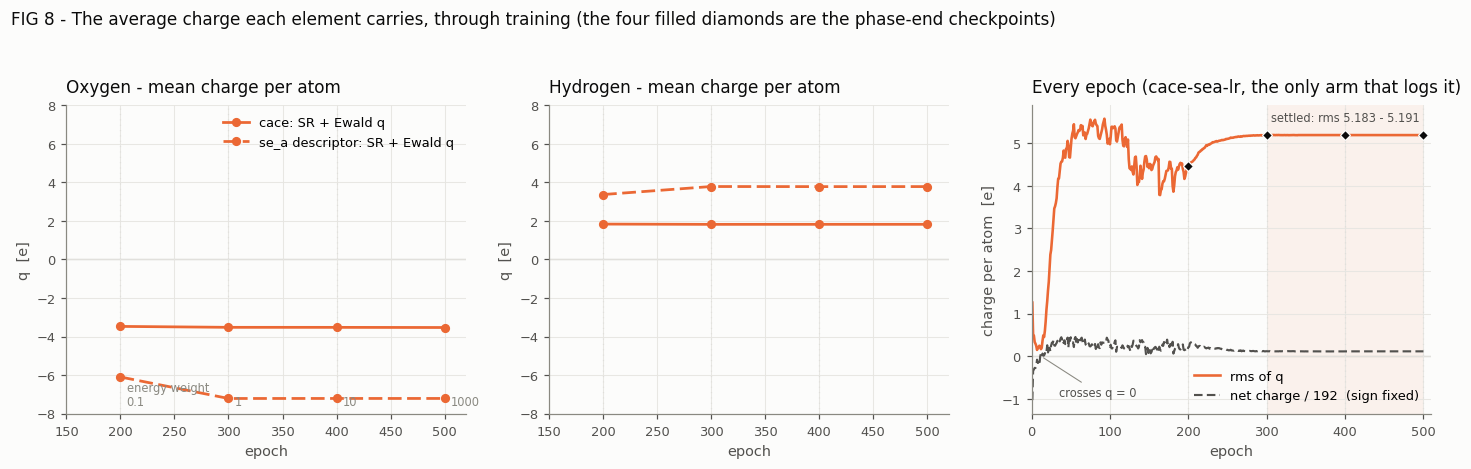

                   q_mean            q_sd        
elem                    H       O       H       O
arm         epoch                                
cace-lr     200.0  1.8330 -3.4756  0.0974  0.2293
            300.0  1.8184 -3.5237  0.0998  0.2432
            400.0  1.8201 -3.5252  0.1001  0.2442
            500.0  1.8204 -3.5329  0.1001  0.2434
cace-sea-lr 200.0 -3.3653  6.1002  0.1135  0.2262
            300.0 -3.7815  7.2150  0.1212  0.2580
            400.0 -3.7765  7.2137  0.1214  0.2595
            500.0 -3.7780  7.2134  0.1206  0.2595

spread of the per-element MEAN across the 80 frames [e] - small beside q_sd,
so the sd is per-atom heterogeneity rather than frame-to-frame drift:
                      min      max
arm         elem                  
cace-lr     H     0.00604  0.00664
            O     0.01248  0.01359
cace-sea-lr H     0.00607  0.00728
            O     0.01168  0.01411


In [10]:
EC_COLS = ['arm', 'epoch', 'ckpt', 'val_selected', 'elem', 'natoms_elem',
           'nframes', 'q_mean', 'q_sd', 'q_sd_of_frame_mean', 'q_min', 'q_max',
           'net_charge_mean_per_frame']
ec = load('cace_element_charge.tsv', EC_COLS, required=True)

# The global sign of q is an exact gauge: E_LR = q^T K(r) q and F_LR = q^T (dK/dr) q
# are both even in q, and the short-range half never sees q at all. cace-sea-lr's own
# optimizer crossed q = 0 early in training (epoch ~12; third panel) and settled on the
# branch opposite to cace-lr's, so the two arms report opposite signs and neither is
# wrong.
# To read them on one axis the sea arm is flipped to the oxygen-negative branch; the
# flip is auto-detected from that arm's own measured q_O, not hardcoded. The absolute
# level stays in cace's own unit convention (norm_factor 1.0, against 90.4756 in les),
# so the O:H contrast and the trend are what to read, not the scale.
LR_CHARGE_ARMS = [a for a in ('cace-lr', 'cace-sea-lr') if a in set(ec['arm'])]
SIGN = {}
for arm in LR_CHARGE_ARMS:
    qO = ec[(ec['arm'] == arm) & (ec['elem'] == 'O') & (ec['val_selected'] == 0)]
    SIGN[arm] = -1.0 if qO['q_mean'].mean() > 0 else 1.0
print('sign convention (multiply q_mean by): ' + ', '.join(
    f'{a} {SIGN[a]:+.0f}' + ('  <- flipped to the O-negative branch' if SIGN[a] < 0 else '')
    for a in LR_CHARGE_ARMS))

def phase_ends(arm):
    """The four phase-end checkpoints in epoch order. best_model is excluded: it was
    elected on these very 80 frames and collect_sweep.py records no epoch for it, so
    it cannot be placed on a progress axis at all."""
    d = ec[(ec['arm'] == arm) & (ec['val_selected'] == 0)]
    return d.pivot_table(index='epoch', columns='elem', values='q_mean').sort_index()

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.3))
axO, axH, axC = axes
for ax, elem, name in ((axO, 'O', 'Oxygen'), (axH, 'H', 'Hydrogen')):
    for arm in LR_CHARGE_ARMS:
        p = phase_ends(arm)
        ax.plot(p.index, SIGN[arm] * p[elem], marker='o', ms=5, lw=1.8,
                label=arm_label(arm), **arm_style(arm))
    for e in (200, 300, 400):
        ax.axvline(e, color=INK3, lw=0.7, ls=(0, (1, 4)), alpha=0.75, zorder=0)
    tidy_grid(ax, f'{name} - mean charge per atom', 'epoch', 'q  [e]')
    ax.set_xlim(150, 520)
    ax.axhline(0.0, color=INK3, lw=0.8, alpha=0.6, zorder=0)
# One shared, symmetric y-axis across the two element panels, so the O:H magnitude
# ratio reads as the distance from zero. The four energy-weight steps are marked on
# the left panel only: 0.1 -> 1 -> 10 -> 1000 across the phase boundaries, which is
# why the sea arm steps between its epoch-200 and epoch-300 points.
span = max(abs(ax.get_ylim()[i]) for ax, i in ((axO, 0), (axO, 1), (axH, 0), (axH, 1)))
for ax in (axO, axH):
    ax.set_ylim(-span * 1.06, span * 1.06)
for e, w in ((200, '0.1'), (300, '1'), (400, '10'), (500, '1000')):
    axO.annotate(w, (e, -span * 1.02), xytext=(4, 0), textcoords='offset points',
                 fontsize=7.5, color=INK3, va='bottom')
axO.annotate('energy weight', (200, -span * 1.02), xytext=(4, 9),
             textcoords='offset points', fontsize=7.5, color=INK3, va='bottom')
axO.legend(loc='upper right')

# Third panel: the only per-epoch charge trace we have. `SeaTermLogger` logs all-atom
# aggregates every epoch, so this carries the full 500-epoch resolution the four
# phase-end points above cannot show - and it is the evidence that the charges are
# frozen after epoch ~300, i.e. the four points skip no transient.
tl = terms[terms['arm'] == 'cace-sea-lr'].sort_values('global_epoch')
d = tl.dropna(subset=['val_q_rms'])
nflip = SIGN['cace-sea-lr'] * d['val_q_mean']
settled = d.loc[d['global_epoch'] >= 300, 'val_q_rms']
axC.axvspan(300, 500, color=HUE['lr'], alpha=0.07, lw=0, zorder=0)
axC.plot(d['global_epoch'], d['val_q_rms'], lw=1.7, color=HUE['lr'],
         label='rms of q')
axC.plot(d['global_epoch'], nflip, lw=1.4, color=INK2, ls=(0, (4, 2)),
         label='net charge / 192  (sign fixed)')
axC.axhline(0.0, color=INK3, lw=0.8, alpha=0.6, zorder=0)
for e in (200, 300, 400, 500):
    axC.axvline(e, color=INK3, lw=0.7, ls=(0, (1, 4)), alpha=0.75, zorder=0)
    v = d.loc[d['global_epoch'] == e, 'val_q_rms']
    if len(v):
        axC.plot([e], v, marker='D', ms=4.2, color=INK, mec=SURFACE,
                 mew=0.8, ls='none', zorder=5)
tidy_grid(axC, 'Every epoch (cace-sea-lr, the only arm that logs it)',
          'epoch', 'charge per atom  [e]')
axC.set_xlim(0, 510)
axC.legend(loc='lower right')
up = nflip > 0
x_cross = d['global_epoch'][up & ~up.shift(fill_value=False)].iloc[0]
axC.annotate('crosses q = 0', (x_cross, 0.0), xytext=(12, -26),
             textcoords='offset points', fontsize=7.5, color=INK2,
             arrowprops=dict(arrowstyle='-', lw=0.7, color=INK3))
axC.text(400, axC.get_ylim()[1] * 0.97,
         f'settled: rms {settled.min():.3f} - {settled.max():.3f}',
         fontsize=7.5, color=INK2, ha='center', va='top')
fig.suptitle('FIG 8 - The average charge each element carries, through training '
             '(the four filled diamonds are the phase-end checkpoints)',
             x=0.007, ha='left', fontsize=11, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

print(ec[ec['val_selected'] == 0].pivot_table(
    index=['arm', 'epoch'], columns='elem',
    values=['q_mean', 'q_sd']).round(4).to_string())
print('\nspread of the per-element MEAN across the 80 frames [e] - small beside q_sd,')
print('so the sd is per-atom heterogeneity rather than frame-to-frame drift:')
print(ec[ec['val_selected'] == 0].groupby(['arm', 'elem'])['q_sd_of_frame_mean']
      .agg(['min', 'max']).round(5).to_string())

## FIG 9 - The two levers, priced the same way

Every arm in this campaign differs from some other arm in one of two ways: by the descriptor that feeds its short-range model, or by whether the long-range Ewald term is switched on.
This figure puts both changes on one axis, as the percentage of the error each one removes, so that "the descriptor mattered more than the long-range term" becomes a number instead of an adjective.

The comparison is only meaningful when a pair differs in exactly one effective knob, so every bar is an ablation against a baseline that is otherwise identical.
The two descriptor bars swap `se_a` for cace's own representation inside the same loop, and the four long-range bars add the Ewald term on top of a fixed descriptor with the same `sigma`, `dl` and `remove_self_interaction` throughout.
The descriptor swap is only priceable inside cace's loop - deepmd's loop has no second descriptor to swap to - which is why both descriptor bars sit there, while the long-range lever is priced in both.
`deepmd_sA` and `deepmd_sB` are the short-range controls for the deepmd family, so the two deepmd rows carry both replicates: the bar is their mean and the whisker is their spread.
Every cace or `se_a`-in-cace row is a single run, so those rows carry no spread at all.

Each number is read at the arm's final phase checkpoint, because deepmd step 80000 and cace epoch 500 are the same 500 passes over the same 320 training frames - one checkpoint per arm, one number per arm, and no choice of window.
Force is flat across the last phase (FIG 5), so the force panel needs no window; energy is not, so that panel's title says so and the cell prints all four checkpoints.

Reading the figure:

1. **The descriptor is the larger lever, by most of an order of magnitude.**
   Swapping `se_a` for cace's own representation removes 44.2% of the force error at short range and 51.8% with Ewald, against 25.8% inside cace's loop and 14.0% under `se_a` for the long-range term.
   Against the best the long-range switch manages under `se_a` (5.95%), the descriptor at SR + Ewald is 8.7x larger - and it is large in **both** topologies, not only where the Ewald term is present.
2. **Under `se_a`, most of what the long-range term buys is the classical summation, not the learned charge.**
   Learning the charges removes 5.95% of the force error; freezing them at the SPC/E values removes 5.2%.
   So 87% of that small payoff is Ewald over a fixed charge, and the learned charge layer is worth 0.8 percentage points - inside the 0.9-1.3 point spread between the two deepmd replicates on those rows.
   Those two rows are a clean single-knob ablation: their inputs differ only in `freeze_charge` against `local_charge` + `initial_guess`, with the descriptor, the short-range net, `sigma` / `dl` / `remove_self_interaction` and the learning-rate schedule all identical.
   (`output_scaling_factor` does differ - 1.0 against the 0.1 default - but it only multiplies the learned `Atomwise`, and in freeze mode that module is a dummy, so it is inert there.)
3. **On energy the long-range term is unstable rather than merely small, while the descriptor stays large on every window.**
   The descriptor bars are 46.2% and 57.1% at this checkpoint; the four long-range bars are 22.4 / 2.7 / -18.6 / -0.3.
   The 22.4% is the one that decides how to read the channel: it is +22.4% at step 80000 but -14.3% as a mean over the last phase, so it is a value at a checkpoint and not a converged effect, and the two deepmd rows are negative on every window.
   On that same channel the learned charges are, if anything, worse than the frozen ones - sA 6.231e-4 against 5.615e-4 eV/atom, sB the same way round - which is the opposite of a story in which the charge layer is what a long-range term needs.
4. **The long-range term pays in proportion to the short-range model underneath it.**
   The same Ewald block is worth 25.8% of the force error inside cace's loop and 5.95% under `se_a`, a 4.3x difference produced by the descriptor alone.
   That is the ordering the whole campaign points at: a good short-range model is what makes a long-range term worth adding, and no long-range term rescues a descriptor that is behind.

Two limits to state plainly.
The cace and `se_a`-in-cace bars are single runs, so the only spread on this figure is the two deepmd replicates, and it is shown rather than assumed to be typical.
And the charge-neutrality probe is printed below the figure rather than drawn on it: its `q_O` / `q_H` ratio is exactly -2 by construction, an arithmetic identity of the `sum(q) = 0` constraint rather than a learned result, so it cannot take a bar beside the learned arms.

valid_sweep.tsv                   40 rows   arms ['deepmd-les-claim-neutral_sA', 'deepmd-les-claim-neutral_sB', 'deepmd-les-freeze-charge_sA', 'deepmd-les-freeze-charge_sB', 'deepmd-les_sA', 'deepmd-les_sB', 'deepmd_sA', 'deepmd_sB']
valid_sweep_sea.tsv              100 rows   arms ['deepmd-cace-sched_sA', 'deepmd-cace-sched_sB', 'deepmd-les-cace-sched_sA', 'deepmd-les-cace-sched_sB']


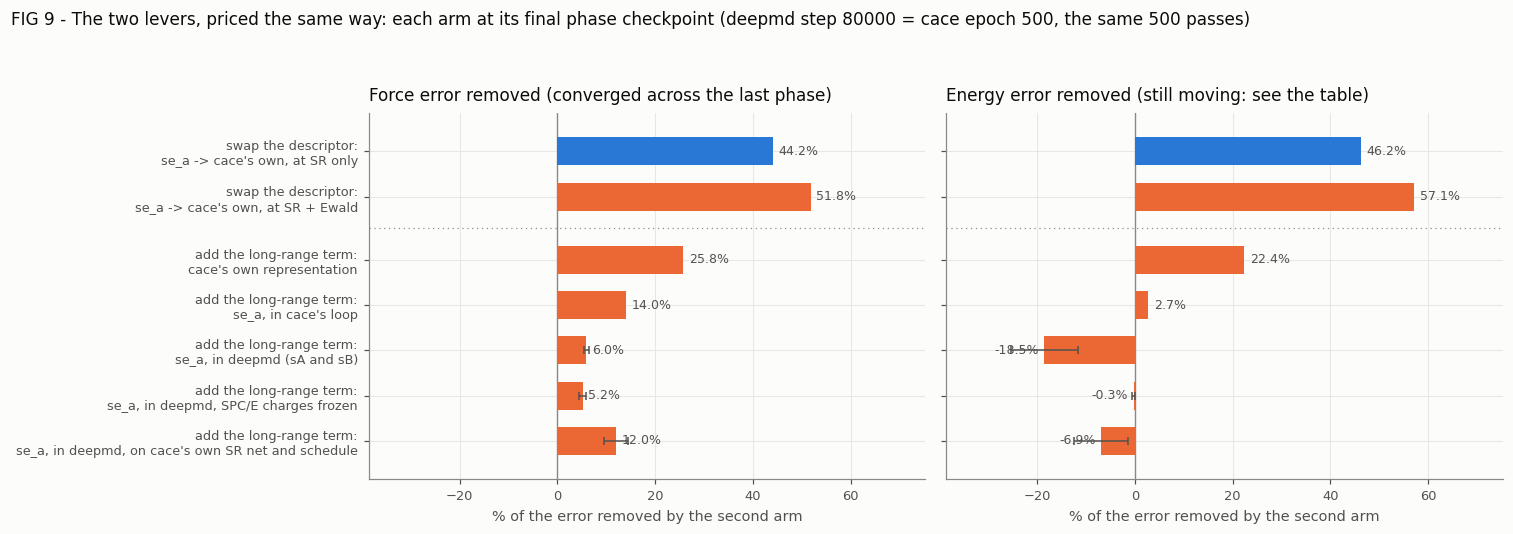

the figure's numbers, spelled out at the final phase checkpoint:

  force   (rmse at the final checkpoint, then what the second arm removes)
    cace-sea-sr                    4.634299e-02  ->  cace-sr                        2.588108e-02   +44.15%
    cace-sea-lr                    3.985954e-02  ->  cace-lr                        1.921636e-02   +51.79%
    cace-sr                        2.588108e-02  ->  cace-lr                        1.921636e-02   +25.75%
    cace-sea-sr                    4.634299e-02  ->  cace-sea-lr                    3.985954e-02   +13.99%
    deepmd_sA                      5.602303e-02  ->  deepmd-les_sA                  5.295727e-02    +5.47%
    deepmd_sB                      5.762681e-02  ->  deepmd-les_sB                  5.391993e-02    +6.43%
    deepmd_sA                      5.602303e-02  ->  deepmd-les-freeze-charge_sA    5.349132e-02    +4.52%
    deepmd_sB                      5.762681e-02  ->  deepmd-les-freeze-charge_sB    5.428335e-02    +5.80%
   

In [11]:
SW_COLS = ['arm', 'step', 'rmse_e_peratom', 'rmse_f', 'natoms', 'nframes']
sw = pd.concat([load('valid_sweep.tsv', SW_COLS, required=True),
                load('valid_sweep_sea.tsv', SW_COLS)], ignore_index=True)

def final_errors(arm):
    """(rmse_f, rmse_e_peratom) at the arm's own final phase checkpoint.

    Both families end at the same amount of work - deepmd step 80000 and cace epoch
    500 are each 500 passes over the same 320 training frames - so one checkpoint per
    arm is one number per arm and no choice of window. Force is flat across the last
    phase (FIG 5); energy is not, which is why the energy panel says so and every
    checkpoint is printed below rather than quietly averaged.
    """
    if arm in set(scored['arm']):
        d, key = scored[scored['arm'] == arm], 'epoch'
    elif arm in set(sw['arm']):
        d, key = sw[sw['arm'] == arm], 'step'
    else:
        raise ValueError(f'{arm}: no rows in cace_valid/cace_sea_valid/valid_sweep')
    last = d[key].max()
    d = d[d[key] == last]
    if len(d) != 1:
        raise ValueError(f'{arm}: {len(d)} rows at {key} {last}, expected exactly 1')
    return float(d['rmse_f'].iloc[0]), float(d['rmse_e_peratom'].iloc[0])


def topology(arm):
    """Which of the two campaign topologies an arm name belongs to. Hue carries
    topology in every figure in this notebook, never the descriptor."""
    return 'lr' if ('-lr' in arm or 'les' in arm) else 'sr'


def leverage(pairs, channel):
    """% of the error the SECOND arm of each pair removes relative to the first, one
    value per replicate. Returns (mean, half-range, the per-replicate values)."""
    i = 0 if channel == 'force' else 1
    pct = [100.0 * (1.0 - final_errors(b)[i] / final_errors(a)[i]) for a, b in pairs]
    return float(np.mean(pct)), (float(np.ptp(pct) / 2) if len(pct) > 1 else 0.0), pct


# One row per ablation, and every ablation moves ONE knob pair: the baseline is the
# first arm, the arm that gains is the second, and the hue is that second arm's
# topology. The two deepmd rows carry both replicates (sA, sB), so their bar is the
# replicate mean and the whisker is the replicate spread - which is what decides
# whether a difference is bigger than the seed.
ROWS = [
    ("swap the descriptor:\nse_a -> cace's own, at SR only",
     [('cace-sea-sr', 'cace-sr')]),
    ("swap the descriptor:\nse_a -> cace's own, at SR + Ewald",
     [('cace-sea-lr', 'cace-lr')]),
    ("add the long-range term:\ncace's own representation",
     [('cace-sr', 'cace-lr')]),
    ("add the long-range term:\nse_a, in cace's loop",
     [('cace-sea-sr', 'cace-sea-lr')]),
    ("add the long-range term:\nse_a, in deepmd (sA and sB)",
     [('deepmd_sA', 'deepmd-les_sA'), ('deepmd_sB', 'deepmd-les_sB')]),
    ("add the long-range term:\nse_a, in deepmd, SPC/E charges frozen",
     [('deepmd_sA', 'deepmd-les-freeze-charge_sA'),
      ('deepmd_sB', 'deepmd-les-freeze-charge_sB')]),
]

# The matched-implementation pair: deepmd's own training loop driving cace's SR net and
# its entire schedule, so the Ewald term is the only knob left between the two arms.
# Added per replicate and only when BOTH halves are scored, so the figure never draws a
# bar from a single arm - it starts as one pair and becomes two as the second lands.
MATCH_PAIRS = [(a, b) for a, b in
               [('deepmd-cace-sched_sA', 'deepmd-les-cace-sched_sA'),
                ('deepmd-cace-sched_sB', 'deepmd-les-cace-sched_sB')]
               if a in set(sw['arm']) and b in set(sw['arm'])]
if MATCH_PAIRS:
    ROWS.append(("add the long-range term:\nse_a, in deepmd, on cace's own SR net and schedule",
                 MATCH_PAIRS))

if not HAVE_SEA_PHASE:
    print('SKIP FIG 9: the descriptor bars need a cace AND a cace-sea phase checkpoint,')
    print('          so with only one family scored the figure would show one group.')
else:
    V = {(chan, lab): leverage(pairs, chan)
         for chan in ('force', 'energy') for lab, pairs in ROWS}
    lo = min(v - e for v, e, _ in V.values())
    hi = max(v + e for v, e, _ in V.values())
    span = hi - lo
    # one x-axis for both panels: the two levers can then be compared by bar length
    # across panels as well as within one, which is what "priced the same way" means
    XLIM = (lo - 0.16 * span, hi + 0.22 * span)

    # Row positions, top down, one extra gap where the descriptor group ends and the
    # long-range group begins. Derived from ROWS so appending a row needs no new numbers.
    GAP_AFTER = 2
    Y = []
    top = 6.0
    for i in range(len(ROWS)):
        if i == GAP_AFTER:
            top -= 0.4
        Y.append(round(top, 6))
        top -= 1.0
    fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.9), sharey=True, sharex=True)
    for ax, chan, title in (
            (axes[0], 'force', 'Force error removed (converged across the last phase)'),
            (axes[1], 'energy', 'Energy error removed (still moving: see the table)')):
        for y, (lab, pairs) in zip(Y, ROWS):
            v, e, _ = V[(chan, lab)]
            ax.barh(y, v, height=0.62, color=HUE[topology(pairs[0][1])], zorder=3,
                    xerr=(e if e else None),
                    error_kw=dict(ecolor=INK2, lw=1.0, capsize=2.5, zorder=4))
            # One number per bar. The replicates' spread is the whisker, not a second
            # label: the energy row's range string is wide enough to run off the axis.
            ax.text(v + np.sign(v if v else 1) * 0.014 * span, y, f'{v:.1f}%',
                    va='center', ha='left' if v >= 0 else 'right', fontsize=8.2,
                    color=INK2)
        ax.axvline(0.0, color=INK3, lw=0.9, zorder=2)
        # the two groups: swapping the descriptor, and adding the long-range term
        ax.axhline((Y[GAP_AFTER - 1] + Y[GAP_AFTER]) / 2, color=INK3, lw=0.8,
                   ls=(0, (1, 3)), zorder=1)
        ax.set_xlim(*XLIM)
        tidy_grid(ax, title, '% of the error removed by the second arm')
    axes[0].set_yticks(Y)
    axes[0].set_yticklabels([lab for lab, _ in ROWS], fontsize=8.4)
    axes[0].set_ylim(min(Y) - 0.85, max(Y) + 0.85)
    fig.suptitle('FIG 9 - The two levers, priced the same way: each arm at its final phase '
                 'checkpoint (deepmd step 80000 = cace epoch 500, the same 500 passes)',
                 x=0.007, ha='left', fontsize=11, color=INK)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()

    print("the figure's numbers, spelled out at the final phase checkpoint:")
    for chan, i in (('force', 0), ('energy', 1)):
        print(f'\n  {chan}   (rmse at the final checkpoint, then what the second arm removes)')
        for lab, pairs in ROWS:
            for a, b in pairs:
                ea, eb = final_errors(a)[i], final_errors(b)[i]
                print(f'    {a:30s} {ea:.6e}  ->  {b:30s} {eb:.6e}   '
                      f'{100 * (1 - eb / ea):+6.2f}%')
    print('\nall four checkpoints, so the movement is visible rather than averaged:')
    print(scored[['arm', 'epoch', 'rmse_f', 'rmse_e_peratom']]
          .sort_values(['arm', 'epoch']).to_string(index=False))
    print(sw[['arm', 'step', 'rmse_f', 'rmse_e_peratom']]
          .sort_values(['arm', 'step']).to_string(index=False))

    print('\nthe same lever averaged over the LAST PHASE instead of one checkpoint.')
    print('FORCE is flat across that phase, so the two agree; ENERGY is not, so its')
    print('column here is indicative and the checkpoint column the figure draws is the')
    print('one to quote:')

    def phase_errors(arm):
        """(rmse_f, rmse_e) averaged over the arm's last phase."""
        if arm in set(scored['arm']):
            d, key, first = scored[scored['arm'] == arm], 'epoch', 300
        else:
            d, key, first = sw[sw['arm'] == arm], 'step', 60000
        d = d[d[key] >= first]
        return float(d['rmse_f'].mean()), float(d['rmse_e_peratom'].mean())

    for chan, i in (('force', 0), ('energy', 1)):
        print(f'\n  {chan}')
        for lab, pairs in ROWS:
            pct = [100.0 * (1 - phase_errors(b)[i] / phase_errors(a)[i])
                   for a, b in pairs]
            rng = f'   ({min(pct):.1f} to {max(pct):.1f})' if len(pct) > 1 else ''
            print(f'    mean {np.mean(pct):+6.2f}%{rng:24s} {lab.replace(chr(10), " ")}')

    print('\nthe charge-neutrality probe, printed rather than drawn: its q_O/q_H ratio is')
    print('exactly -2 by construction (the charges are projected onto sum(q) = 0), so it')
    print('is an arithmetic identity of the constraint, not a learned result, and it does')
    print('not belong on a bar beside the learned arms:')
    cn = [('deepmd_sA', 'deepmd-les-claim-neutral_sA'),
          ('deepmd_sB', 'deepmd-les-claim-neutral_sB')]
    for chan, i in (('force', 0), ('energy', 1)):
        v, e, raw = leverage(cn, chan)
        print(f'  {chan:6s} {v:+6.2f}% +/- {e:.2f}  '
              f'(replicates {", ".join(f"{x:+.2f}" for x in raw)})')

## Findings

Both `se_a` arms finished the same 500-epoch (80,000-step) recipe as the campaign's cace arms, on the same 320 training frames and the same 80 scored frames, so every number here is a matched comparison - same schedule, same losses, same phases, only the representation differs.

**The descriptor swap costs about 1.8x on force, and the same factor on the converged energy.**
Replacing cace's own representation with deepmd's `se_a` (1600 features, 112 neighbours, four embedding networks) moves the mean force error over the four phase checkpoints from 2.63e-2 to 4.87e-2 eV/Å when both arms are SR-only, and from 2.17e-2 to 4.62e-2 when both carry the Ewald term.
The validation-selected checkpoints give the same factors (1.79x and 2.07x), so this is not an artifact of which checkpoint is picked.
On energy the means are not comparable across arms - cace's `fit` raises the energy weight from 0.1 to 1.0 at epoch 200, and the `se_a` arm starts that phase from a much worse energy (4.93 meV at epoch 200 against 0.44 meV at epoch 300) - so the honest energy comparison is the converged one: 0.434 meV for `cace-sea-sr` against 0.236 meV for `cace-sr`, i.e. 1.84x, the same factor as force.
A ~1.8x penalty on both channels from the descriptor alone is the single largest effect in this pair of runs.

**The long-range channel is worth less to the weaker descriptor.**
Under cace's recipe the Ewald term is worth 17.6% of the force error on the four-checkpoint mean and 25.8% at the last checkpoint (2.1711e-2 against 2.6345e-2; 1.9216e-2 against 2.5881e-2).
Under `se_a` it is worth 5.1% on the mean and 14.0% at the last checkpoint (4.6182e-2 against 4.8674e-2; 3.9860e-2 against 4.6343e-2).
It is still a real gain, but roughly half to a third as large, and the descriptor error it is added to is three times bigger.
On energy the transfer fails outright: under cace the Ewald term buys 22% at the last checkpoint (0.185 against 0.239 meV), under `se_a` it buys nothing once converged (0.432 against 0.444 meV, 0.973x).
The 67% energy win `cace-sea-lr` appears to show on the four-point mean is confined to the epoch-200 point - its energy is already 0.723 meV there while `cace-sea-sr` sits at 4.93 meV - so what the long-range term buys under `se_a` is energy *convergence speed*, not converged energy accuracy.

**The `se_a` arm spends far more of its force on the long-range term, with heavier cancellation.**
`F_LR/F_Tot` settles at 0.237 for `cace-sea-lr` against 0.094 for `cace-lr`, and it is steady over the last three checkpoints (0.2363, 0.2367, 0.2363), so it is a converged property rather than a transient of the phase schedule.
The charges behind it are about twice as large: `sum q^2` is 5163 per frame against 1228, i.e. an rms of 5.19 e per atom against 2.53 e.
Because the kernel keeps the self term (`remove_self_interaction=False` in both codes), `F_Self/F_Tot` reaches 1.05 in the `se_a` arm - the self term's gradient is larger than the total force it is a part of, so the Ewald force is a difference of two large and nearly equal contributions.
In float32 that still leaves about six significant digits, so the split in FIG 3 and FIG 7 is measured and not noise; the thing to read from those numbers is the charge scale the free fit settles on, not a defect of the seam.
Both arms also carry a nonzero net charge per frame (+6.9 e for `cace-lr`, -21.9 e for `cace-sea-lr`), which is cace's own convention rather than something the seam introduces.

**What this says about the seam and about where the error lives.**
The seam works: both arms trained to completion, wrote five checkpoints each, and every force is the gradient of a named energy, so the SR / LR split is measured rather than modelled.
The `se_a` descriptor runs the campaign's loop unmodified - only its output width (1600) and the SR head that consumes it differ.
What it costs is a flatter and ~1.8x worse error surface, and that cost is not recoverable by the long-range term: the descriptor, not the electrostatics, is where this pair's error budget sits.
The one place the long-range term clearly still earns its keep under `se_a` is how fast the energy settles in phase 1, which would matter if the schedule were ever shortened.

Both `best_model.pth` files are excluded from every mean above and shown as flagged points instead, for the two reasons in FIG 6.


## Appendix - how these figures are encoded

Hue carries the **arm topology** - blue for the short-range-only arms, orange for the arms that add the Ewald sum - reusing the campaign's own semantics for those two slots.
Line style carries the **descriptor**: solid for cace's `Cace` representation, dashed for DeepMD's `se_a`, because the descriptor is the one thing that differs between a cace arm and its `se_a` counterpart.

No fifth hue is introduced: the campaign's palette validator fails the amber<->orange pair on the normal-vision floor, and amber is already in use for a deepmd arm, so a new hue could not be separated from the existing set.

Two local exceptions, both inside a single-arm panel where no cross-arm identity is at stake, and both named in their legends: FIG 3 panels 2-3 distinguish the two channels of the `se_a + Ewald` arm by line style, and FIG 2 draws the derived `E_SR + E_LR` total as a neutral dotted reference.

Every figure keeps its legend in ink (text never wears the series colour), and every number behind every mark is in the TSVs under `data/` - the table view. FIG 6 additionally prints the arm id on each row's axis label, so identity there is literal text, not colour.

The validation-selected checkpoint wears neither a hue nor a mean: it is drawn as an open circle (FIG 6) or a grey dashed tick (FIG 7), and the number behind it is printed beside each row, because a checkpoint chosen on the scored frames can be reported but must never be averaged into them.
FIG 8 marks the four phase-end checkpoints with filled ink diamonds and leaves the validation-selected one off the axis altogether, because `collect_sweep.py` records no epoch for it and so it cannot be placed on a progress axis at all.

FIG 9 prices one knob per bar rather than one arm per mark, so it keeps the same hue semantics (blue only where the gaining arm is short-range-only, orange where it adds the Ewald sum) and carries identity in its row labels rather than in a legend, exactly as FIG 6 and FIG 7 carry it in their axis labels.
Its whiskers are the replicate spread of the two DeepMD runs, not a fit error, and its energy panel's title carries the convergence warning that its force panel does not need.
